<a href="https://colab.research.google.com/github/AmedeeRoy/BirdGAN/blob/main/code/basicGAN/basicGAN_20_steps_flower.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# GAN

In [1]:
# mount google drive
from google.colab import drive
drive.mount("/content/drive/")

Drive already mounted at /content/drive/; to attempt to forcibly remount, call drive.mount("/content/drive/", force_remount=True).


In [2]:
%cd drive/My\ Drive/

/content/drive/My Drive


## load data

In [3]:
# import python libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import pickle
import datetime as dt
import time
import torch
from torch import nn
from torch import optim
from torch.utils.data import DataLoader, Dataset
import torchvision as tv

# home made
from utils.tools import *

In [4]:
def create_loop():

  a = np.random.uniform(low = 2, high = 5)

  A = np.random.uniform(low = 0.5, high = 1)

  t = np.arange(0, np.pi/a, 0.1)

  x = A * np.sin(a * t) * np.cos(t)
  y = A * np.sin(a * t) * np.sin(t)

  return x, y

In [5]:
### LOOPS

nb_traj = 100
padding = 20
traj = np.zeros((nb_traj, 2, padding))

for i in range(nb_traj):
    x,y = create_loop()

    traj[i,0,:len(x)] = x
    traj[i,1,:len(y)] = y

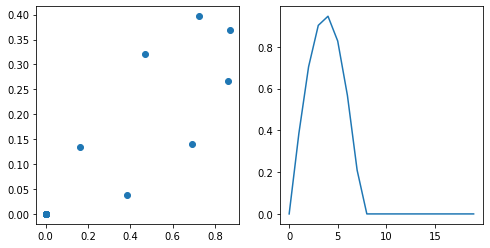

In [6]:
plt.figure(figsize = (8,4))

x = traj[0,0,:]
y = traj[0,1,:]

plt.subplot(1,2, 1)
plt.scatter(x, y)

plt.subplot(1,2, 2)
plt.plot(np.sqrt(x**2 + y**2))

In [7]:
class TrajDataSet(Dataset):
    def __init__(self,  traj, transform=None):
        
        self.traj = traj   # save trips
        self.transform = transform

    def __len__(self):
        return self.traj.shape[0]

    def __getitem__(self, idx):
        sample = traj[idx,:]
        if self.transform:
            sample = self.transform(sample)
        return sample

class ToTensor(object):
    """Convert ndarrays in sample to Tensors."""
    def __call__(self, sample):
        return torch.FloatTensor(sample)

In [8]:
# hyperparameters
batch_size = 20

## reduce size dataset
train_set = TrajDataSet(traj, transform= ToTensor())
train_loader = DataLoader(train_set, batch_size=batch_size, num_workers = 0, shuffle = True, drop_last=True)

In [9]:
x =  next(iter(train_loader))

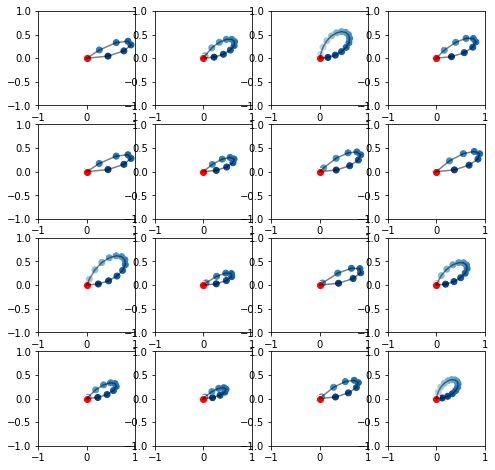

In [10]:
plt.figure(figsize = (8,8))
for i in range(16):
  plt.subplot(4,4,i+1)
  plt.plot(x.numpy()[i,0,:], x.numpy()[i,1,:], c = 'black', alpha = 0.5)
  plt.scatter(x.numpy()[i,0,:], x.numpy()[i,1,:], c=np.arange(padding), cmap='Blues_r')
  plt.scatter(0,0, c = 'red')
  plt.xlim(-1,1)
  plt.ylim(-1,1)


## deep networks

Architecture guidelines for stable Deep Convolutional GANs (Radford et al. 2016)

- Replace any pooling layers with strided convolutions (discriminator) and fractional-strided
convolutions (generator).
- Use batchnorm in both the generator and the discriminator.
- Remove fully connected hidden layers for deeper architectures.
- Use ReLU activation in generator for all layers except for the output, which uses Tanh.
- Use LeakyReLU activation in the discriminator for all layers.



In [11]:
import torch
from torch import nn
from torch import optim
import torchvision as tv
from torchvision.datasets import ImageFolder
from torch.utils.data import DataLoader

## CNN

In [12]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

In [13]:
class CNNGenerator(nn.Module):
    def __init__(self):
        super().__init__()

        self.cnn = nn.Sequential(    
            nn.ConvTranspose1d(20, 10, kernel_size = 5, stride = 2, padding = 0, bias = False),
            nn.BatchNorm1d(10),
            nn.ReLU(True),

            nn.ConvTranspose1d(10, 5, kernel_size = 4, stride = 2, padding = 1, bias = False),
            nn.BatchNorm1d(5),
            nn.ReLU(True),

            nn.ConvTranspose1d(5, 2, kernel_size = 4, stride = 2, padding = 1, bias = False),
            nn.Tanh()
         )
        

    def forward(self, z, batch_size):    
        out = self.cnn(z)
        return out

In [14]:
gen = CNNGenerator().to(device)
z = torch.rand((batch_size, padding, 1)).to(device) # (batch, seq, feature)

out = gen(z, batch_size)
out.shape

torch.Size([20, 2, 20])

In [15]:
class CNNDiscriminator(nn.Module):
    def __init__(self):
        super().__init__()
        
        self.cnn = nn.Sequential(
            
            nn.Conv1d(2, 5, kernel_size = 5, stride = 1, padding = 2, bias = False),
            nn.BatchNorm1d(5),
            nn.LeakyReLU(0.2, inplace=False),

            nn.Conv1d(5, 10, kernel_size = 4, stride = 2, padding = 1, bias = False),
            nn.BatchNorm1d(10),
            nn.LeakyReLU(0.2, inplace=False),

            nn.Conv1d(10, 20, kernel_size = 4, stride = 2, padding = 1, bias = False),
            nn.BatchNorm1d(20),
            nn.LeakyReLU(0.2, inplace=False),

            nn.Conv1d(20, 1, kernel_size=5, stride=2, padding=0, bias=False),
            nn.Sigmoid()
        )

    def forward(self, x, batch_size):

        out = self.cnn(x)

        return out.squeeze(1)


In [16]:
dis = CNNDiscriminator().to(device)
dis(out, batch_size).shape

torch.Size([20, 1])

In [17]:
sum(p.numel() for p in gen.parameters())

1270

# LSTM

In [18]:
class LSTMGenerator(nn.Module):
    """An LSTM based generator. It expects a sequence of noise vectors as input.
    Args:
        in_dim: Input noise dimensionality
        out_dim: Output dimensionality
        n_layers: number of lstm layers
        hidden_dim: dimensionality of the hidden layer of lstms
    Input: noise of shape (batch_size, seq_len, in_dim)
    Output: sequence of shape (batch_size, seq_len, out_dim)
    """
    def __init__(self):
        super().__init__()

        self.lstm = nn.LSTM(1, 16, 1, batch_first=True, bias = True)
        self.linear = nn.Sequential(
                        nn.ReLU(),
                        nn.Linear(16, 16),
                        nn.ReLU(),
                        nn.Linear(16, 2),
                        nn.Tanh()
                      )

    def forward(self, x, batch_size):  

        h_0 = torch.autograd.Variable(torch.randn(1, batch_size, 16)).to(device) #hidden state
        c_0 = torch.autograd.Variable(torch.randn(1, batch_size, 16)).to(device) #hidden state

        # init LSTM cells  (batch, seq, feature)
        out, h_n = self.lstm(x, (h_0, c_0))
        out = self.linear(out)
        out = out.view(batch_size, 2, padding)
        return torch.cumsum(out, 2)

In [19]:
gen = LSTMGenerator().to(device)
z = torch.rand((batch_size, padding, 1)).to(device) # (batch, seq, feature)

out = gen(z, batch_size)
out.shape

torch.Size([20, 2, 20])

In [20]:
sum(p.numel() for p in gen.parameters())

1522

In [21]:
class LSTMDiscriminator(nn.Module):
    """An LSTM based generator. It expects a sequence of noise vectors as input.
    Args:
        in_dim: Input noise dimensionality
        out_dim: Output dimensionality
        n_layers: number of lstm layers
        hidden_dim: dimensionality of the hidden layer of lstms
    Input: noise of shape (batch_size, seq_len, in_dim)
    Output: sequence of shape (batch_size, seq_len, out_dim)
    """
    def __init__(self):
        super().__init__()

        self.lstm = nn.LSTM(2, 16, 1, batch_first=True)
        
        self.linear = nn.Sequential(
                        nn.Linear(16, 16),
                        nn.ReLU(),
                        nn.Linear(16, 1),
                        nn.Tanh()
                      )

    def forward(self, x, batch_size):  

        h_0 = torch.autograd.Variable(torch.randn(1, batch_size, 16)).to(device) #hidden state
        c_0 = torch.autograd.Variable(torch.randn(1, batch_size, 16)).to(device) #internal stat

        # init LSTM cells  (batch, seq, feature)
        out = x.view(batch_size, padding, 2)
        out, (h_n, c_n) = self.lstm(out, (h_0, c_0))
        out = self.linear(out)
        out = 1/(1 + torch.exp(-torch.mean(out, 1)))

        return out

In [22]:
dis = LSTMDiscriminator().to(device)
dis(out, batch_size).shape

torch.Size([20, 1])

In [23]:
class GAN :
  """
  This class creates a GAN with: 
   - a Generator network 
   - a Discriminator network
   - a Dataloader object from pytorch
  """
  def __init__(self, generator, discriminator, train_loader, device):
    self.generator = generator.to(device)
    self.discriminator = discriminator.to(device)
    self.device = device
    self.train_loader = train_loader
    
  def train(self, nb_epoch, lr, device):
    """
    This function trains the GAN for nb_epoch with a fiwed learning rate lr
    """                                                       
    criterion = nn.BCELoss()
    optim_d = optim.Adam(discriminator.parameters(), lr= lr, betas=(0.5, 0.999))
    optim_g = optim.Adam(generator.parameters(),lr= lr, betas=(0.5, 0.999))
    score = []

    time_start = time.perf_counter()
    for epoch in range(nb_epoch):
        i = 0

        loss_g_running, loss_d_real_running, loss_d_fake_running = 0, 0, 0
        for _, x in enumerate(self.train_loader):

            batch = x.shape[0]
            
            target_ones = torch.ones((batch, 1), device=self.device)
            target_zeros = torch.zeros((batch, 1), device=self.device)
            
            i+= 1
            #### TRAIN DISCRIMINATOR
            ## true samples
            x = x.to(device)

            self.discriminator.zero_grad()
            pred_real = self.discriminator(x, batch)
            loss_real = criterion(pred_real, target_ones)

            ## false samples
            seq_length =  x.shape[2]
            z = torch.rand((batch, seq_length, 1), device=self.device)
            with torch.no_grad():
                fake_samples = self.generator(z, batch)
            pred_fake = self.discriminator(fake_samples, batch)
            loss_fake = criterion(pred_fake, target_zeros)
            
            # combine
            loss = (loss_real + loss_fake) / 2
            loss.backward()
            optim_d.step()

            loss_d_real_running += loss_real.item()
            loss_d_fake_running += loss_fake.item()
            
            #### TRAIN GENERATOR
            self.generator.zero_grad()
            z = torch.rand((batch, seq_length, 1), device=self.device) 

            generated = self.generator(z, batch)
            classifications = self.discriminator(generated, batch)
            loss = criterion(classifications, target_ones) #+ 0.1 * torch.sum((generated[:,0, 0] - generated[:,0,-1])**2)
            loss.backward()
            optim_g.step()

            loss_g_running += loss.item()

        if epoch%100 == 0:
          traj_sim = self.test(100)
          score.append(get_score(traj, traj_sim))
       
        if epoch%500 == 0:
          print('Epoch [{}/{}] -----------------------------------------------------------------------------'
              .format(epoch+1, nb_epoch, i, len(self.train_loader)))
          print('G: {}, Dr : {}, Df : {}'
              .format(loss_g_running/batch, loss_d_real_running/batch, loss_d_fake_running/batch))
          
          self.plot()


    #run your code
    self.score = score
    self.computation_time = (time.perf_counter() - time_start)

  def test(self, nb):
    """
    This function generates nb trajectories
    """ 
    self.generator.zero_grad()    

    x =  next(iter(self.train_loader))
    seq_length = x.shape[2]

    z = torch.rand((nb, seq_length, 1), device=self.device)
    generated = self.generator(z, nb)
    traj_sim = generated.cpu().detach().numpy()
    return traj_sim

  def plot(self):
    """
    This function plots few trajectories
    """ 
    traj_sim = self.test(16)

    plt.figure(figsize = (8,8))
    for i in range(16):
      plt.subplot(4,4,i+1)
      plt.plot(traj_sim[i,0,:], traj_sim[i,1,:], c = 'black', alpha = 0.5)
      plt.scatter(traj_sim[i,0,:], traj_sim[i,1,:], c=np.arange(traj_sim.shape[2]), cmap='Blues_r')
      plt.scatter(0,0, c = 'red')
      plt.xlim(-1,1)
      plt.ylim(-1,1)

    plt.show()
    plt.close()

  def save(self, name):
    torch.save(self.generator, name+'_G.pt')
    torch.save(self.discriminator, name+'_D.pt')

In [24]:
def weights_init(m):
    """
    This function initializes the model weights randomly from a 
    Normal distribution. This follows the specification from the DCGAN paper.
    https://arxiv.org/pdf/1511.06434.pdf
    Source: https://pytorch.org/tutorials/beginner/dcgan_faces_tutorial.html
    """
    classname = m.__class__.__name__
    if classname.find('Conv') != -1:
        nn.init.normal_(m.weight.data, 0.0, 0.02)
    elif classname.find('BatchNorm') != -1:
        nn.init.normal_(m.weight.data, 1.0, 0.02)
        nn.init.constant_(m.bias.data, 0)

# CNN - CNN

Epoch [1/5000] -----------------------------------------------------------------------------
G: 0.2003696531057358, Dr : 0.1661583364009857, Df : 0.15343671441078185


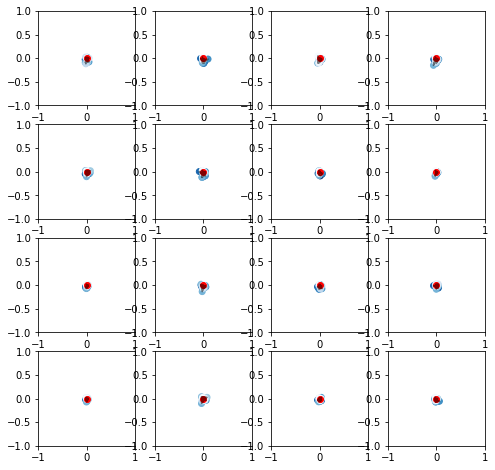

Epoch [501/5000] -----------------------------------------------------------------------------
G: 0.556797182559967, Dr : 0.0595025185495615, Df : 0.045059940218925475


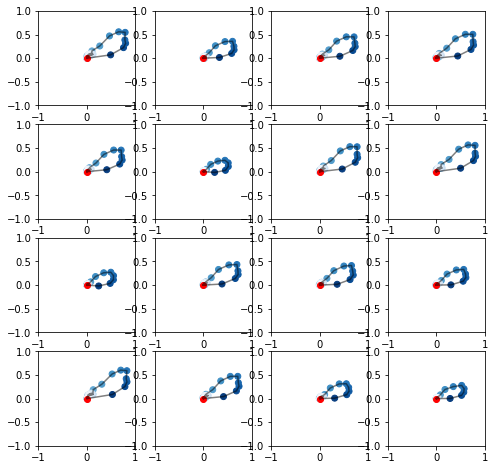

Epoch [1001/5000] -----------------------------------------------------------------------------
G: 0.7315027117729187, Dr : 0.02843228168785572, Df : 0.029207178857177496


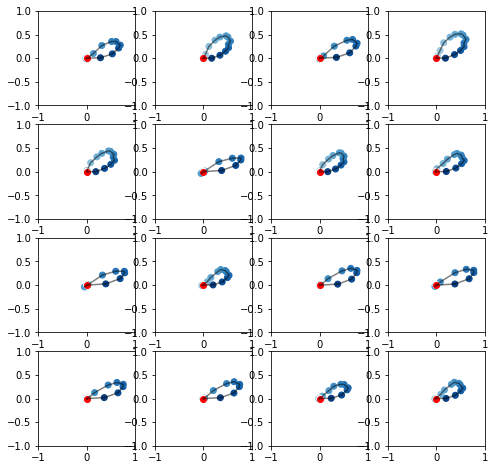

Epoch [1501/5000] -----------------------------------------------------------------------------
G: 0.9061877846717834, Dr : 0.010892997030168772, Df : 0.009265624778345227


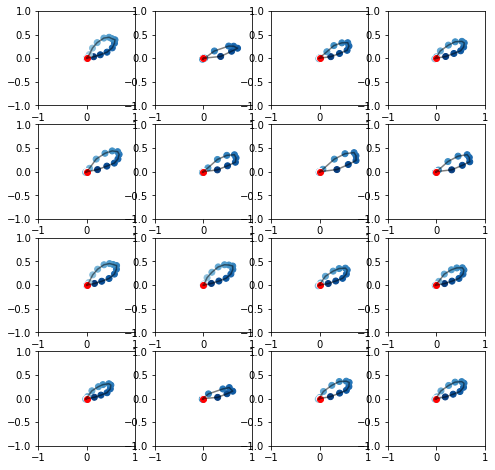

Epoch [2001/5000] -----------------------------------------------------------------------------
G: 1.2909738063812255, Dr : 0.0046111235162243245, Df : 0.003507432295009494


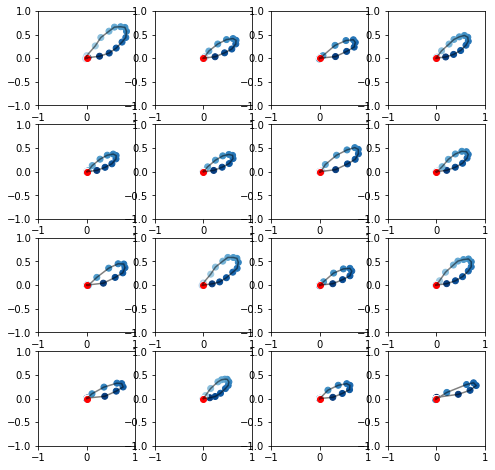

Epoch [2501/5000] -----------------------------------------------------------------------------
G: 1.3486481189727784, Dr : 0.006683431169949472, Df : 0.0034310856135562062


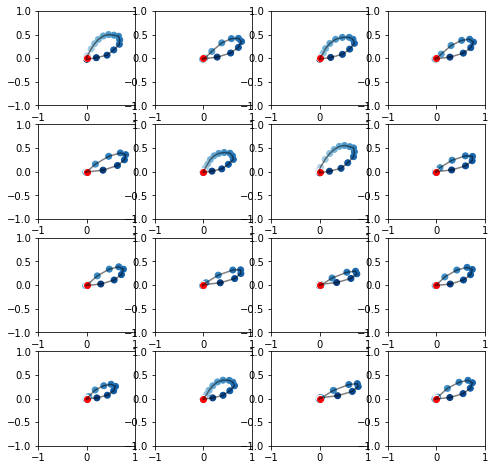

Epoch [3001/5000] -----------------------------------------------------------------------------
G: 1.828063154220581, Dr : 0.0008108598529361188, Df : 0.002006004721624777


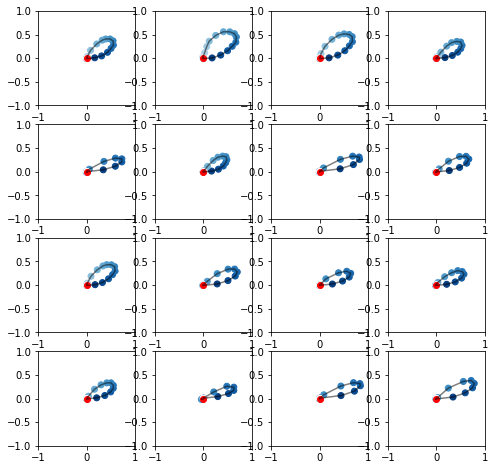

Epoch [3501/5000] -----------------------------------------------------------------------------
G: 1.196428382396698, Dr : 0.006640242727007717, Df : 0.007554883928969502


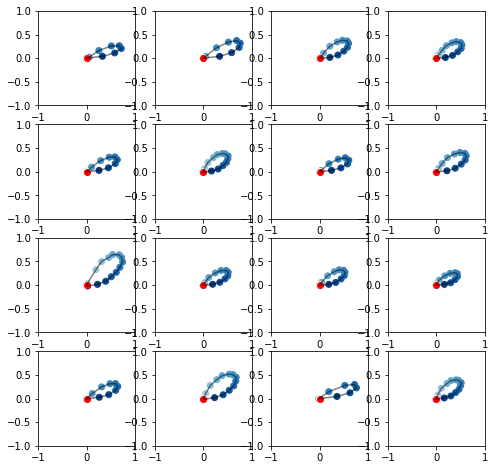

Epoch [4001/5000] -----------------------------------------------------------------------------
G: 1.8841739177703858, Dr : 3.684331404656405e-05, Df : 0.000295092212036252


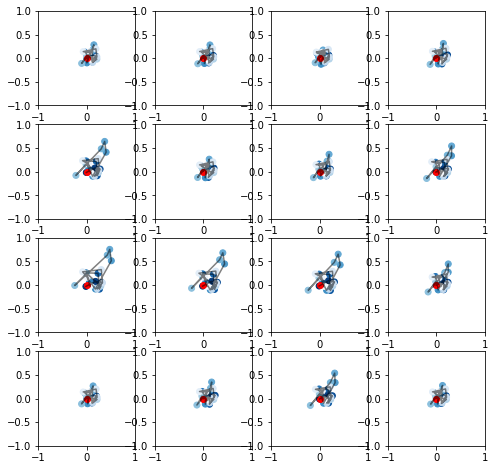

Epoch [4501/5000] -----------------------------------------------------------------------------
G: 1.5901352405548095, Dr : 0.00018673392769414933, Df : 0.0008314358885399998


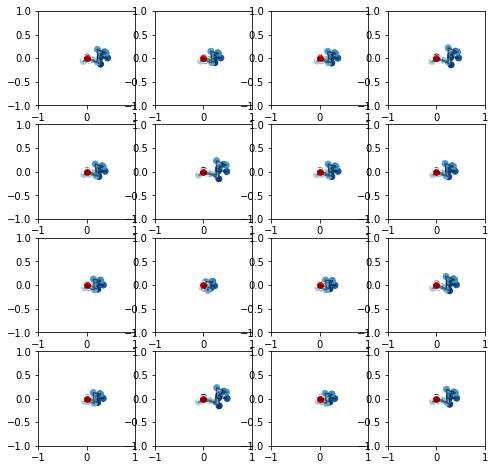

In [25]:
generator = CNNGenerator()
discriminator = CNNDiscriminator()

### WEIGHT INITIALIZATION
generator.apply(weights_init)
discriminator.apply(weights_init)

cnn_cnn = GAN(generator, discriminator, train_loader, device)

# Train the model
nb_epoch = 5000
lr = 0.0002

cnn_cnn.train(nb_epoch, lr, device)

# LSTM - LSTM


Epoch [1/5000] -----------------------------------------------------------------------------
G: 0.15540788769721986, Dr : 0.15192199647426605, Df : 0.19266116619110107


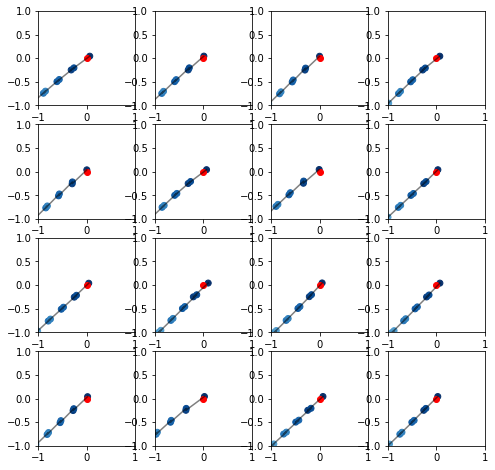

Epoch [501/5000] -----------------------------------------------------------------------------
G: 0.22080563604831696, Dr : 0.14732873439788818, Df : 0.1400766283273697


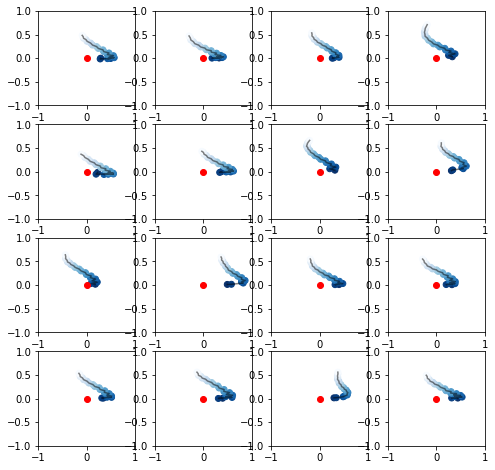

Epoch [1001/5000] -----------------------------------------------------------------------------
G: 0.25028986632823946, Dr : 0.11488961577415466, Df : 0.12022512406110764


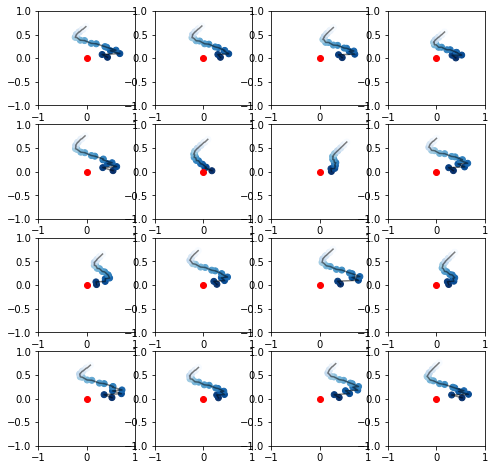

Epoch [1501/5000] -----------------------------------------------------------------------------
G: 0.2690827429294586, Dr : 0.10768332034349441, Df : 0.11292771548032761


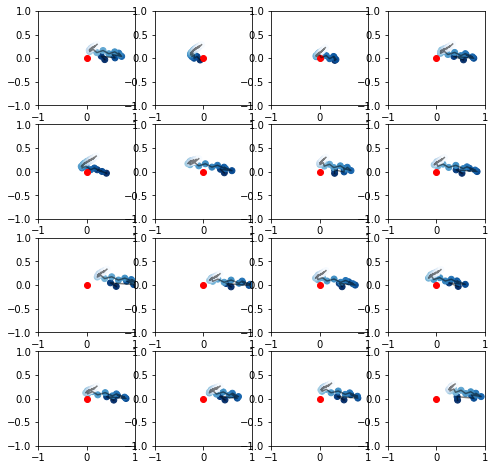

Epoch [2001/5000] -----------------------------------------------------------------------------
G: 0.2812935173511505, Dr : 0.10175480246543885, Df : 0.09969027638435364


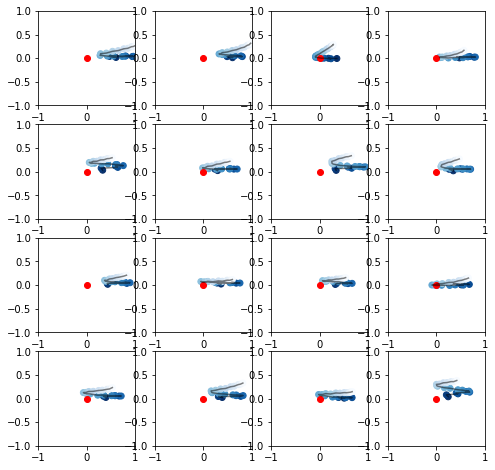

Epoch [2501/5000] -----------------------------------------------------------------------------
G: 0.2817326545715332, Dr : 0.10211721807718277, Df : 0.10178119093179702


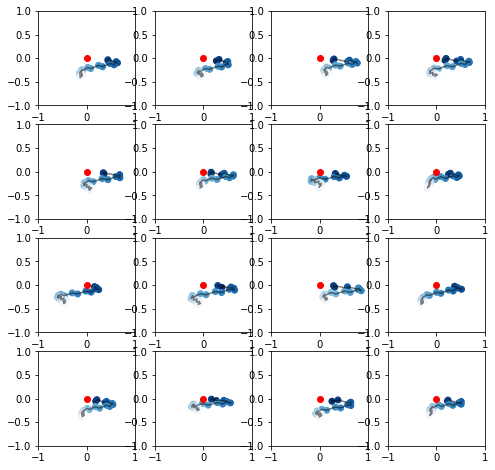

Epoch [3001/5000] -----------------------------------------------------------------------------
G: 0.28361504673957827, Dr : 0.10027151107788086, Df : 0.0979014828801155


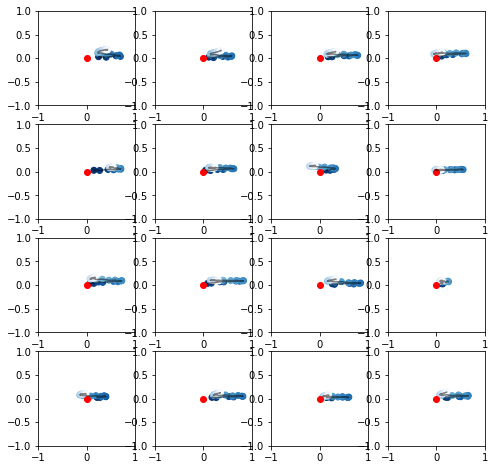

Epoch [3501/5000] -----------------------------------------------------------------------------
G: 0.281356942653656, Dr : 0.10555818378925323, Df : 0.09964499026536941


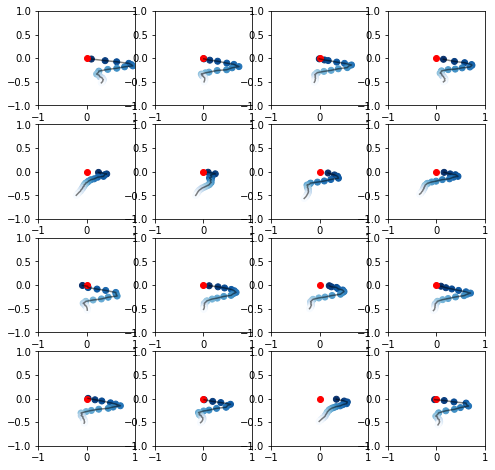

Epoch [4001/5000] -----------------------------------------------------------------------------
G: 0.30151336789131167, Dr : 0.10573943853378295, Df : 0.0914992243051529


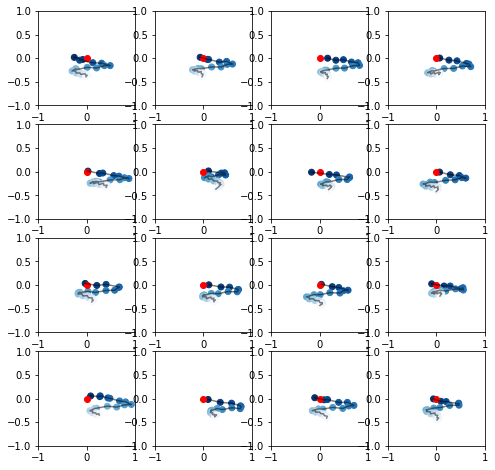

Epoch [4501/5000] -----------------------------------------------------------------------------
G: 0.29023767113685606, Dr : 0.10252169966697693, Df : 0.09401885718107224


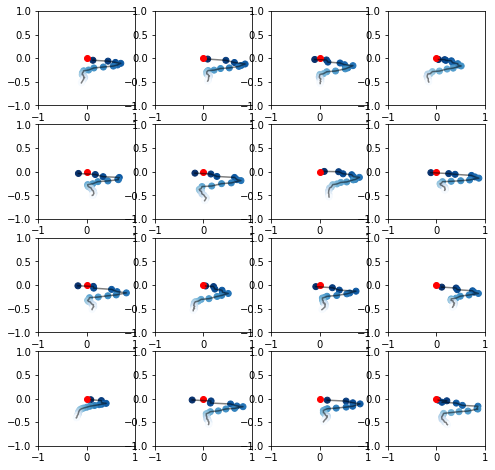

In [26]:
generator = LSTMGenerator().to(device)
discriminator = LSTMDiscriminator().to(device)

# ### WEIGHT INITIALIZATION
# generator.apply(weights_init)
# discriminator.apply(weights_init)

lstm_lstm = GAN(generator, discriminator, train_loader, device)

# Train the model
nb_epoch = 5000
lr = 0.0002

lstm_lstm.train(nb_epoch, lr, device)

# LSTM - CNN

Epoch [1/5000] -----------------------------------------------------------------------------
G: 0.1882314682006836, Dr : 0.19261520504951476, Df : 0.16591877937316896


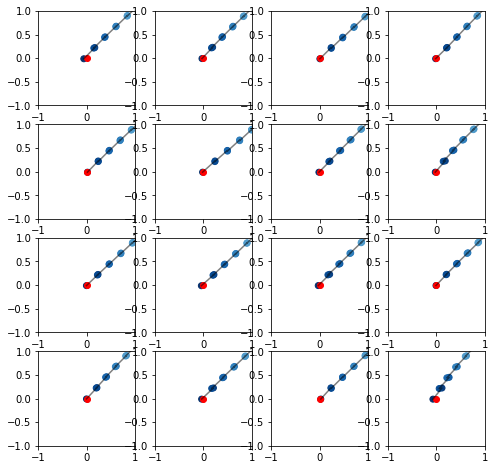

Epoch [501/5000] -----------------------------------------------------------------------------
G: 1.6128624200820922, Dr : 0.00024184710055124014, Df : 0.000477973825763911


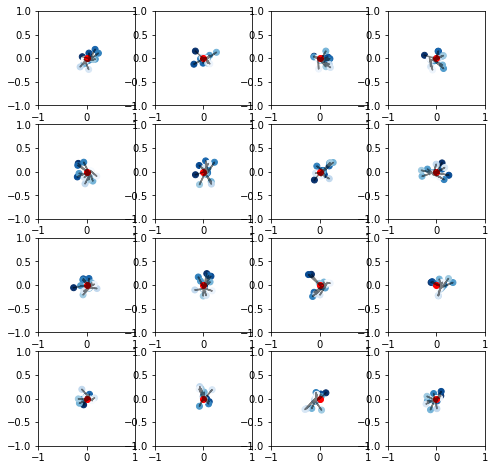

Epoch [1001/5000] -----------------------------------------------------------------------------
G: 2.19431095123291, Dr : 3.7135169259272514e-05, Df : 5.129484270582907e-05


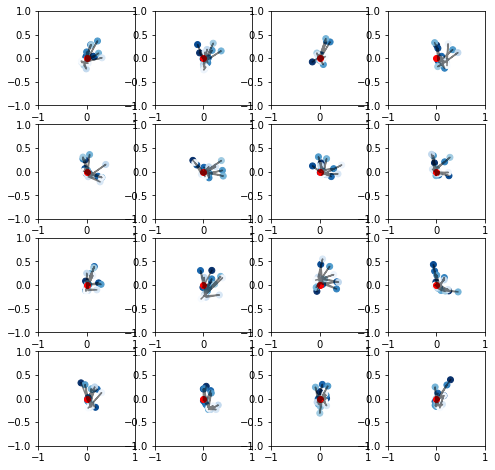

Epoch [1501/5000] -----------------------------------------------------------------------------
G: 2.5512362003326414, Dr : 1.0915548409684562e-05, Df : 1.219002024299698e-05


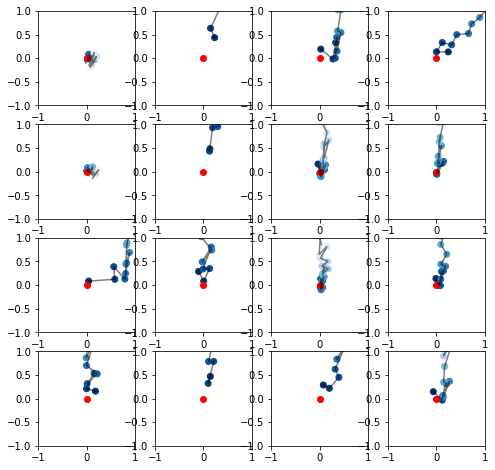

Epoch [2001/5000] -----------------------------------------------------------------------------
G: 2.9284464836120607, Dr : 2.027759410339058e-06, Df : 2.6650968720787205e-06


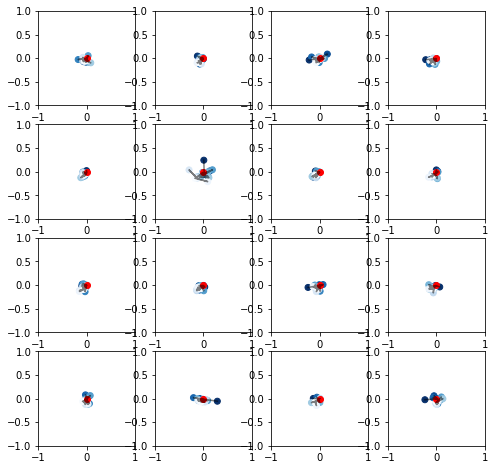

Epoch [2501/5000] -----------------------------------------------------------------------------
G: 3.2712832927703857, Dr : 5.123025061948283e-07, Df : 7.106378347998543e-07


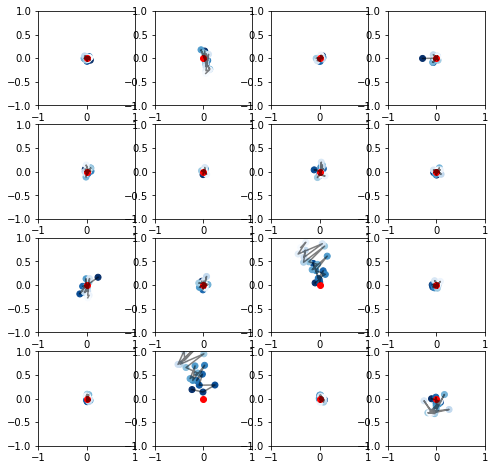

Epoch [3001/5000] -----------------------------------------------------------------------------
G: 3.607643413543701, Dr : 1.603365575419957e-07, Df : 1.9237413084738364e-07


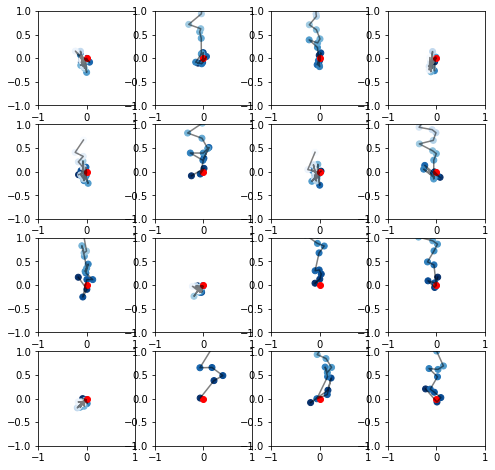

Epoch [3501/5000] -----------------------------------------------------------------------------
G: 3.899302291870117, Dr : 3.7252903695161874e-08, Df : 6.362797648762352e-08


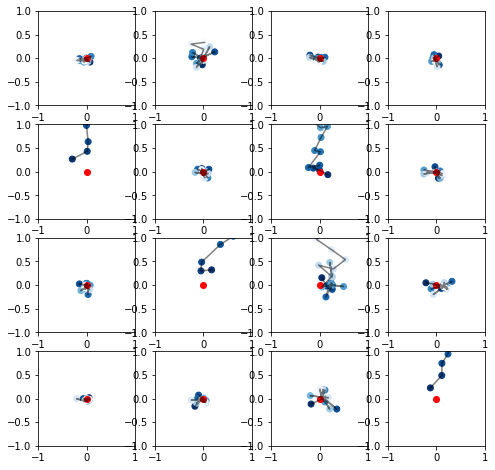

Epoch [4001/5000] -----------------------------------------------------------------------------
G: 4.2980043411254885, Dr : 3.278255533700758e-09, Df : 1.2964010487337418e-08


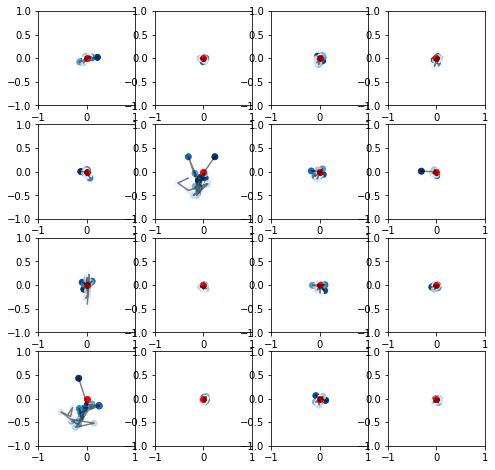

Epoch [4501/5000] -----------------------------------------------------------------------------
G: 4.579891777038574, Dr : 1.4901161415892261e-09, Df : 1.4901161526914563e-09


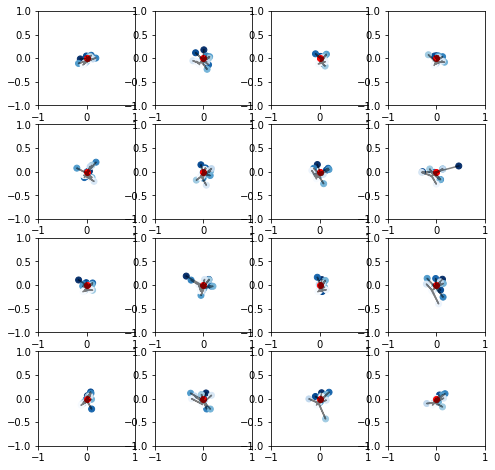

In [27]:
generator = LSTMGenerator().to(device)
discriminator = CNNDiscriminator().to(device)

### WEIGHT INITIALIZATION
generator.apply(weights_init)
discriminator.apply(weights_init)

lstm_cnn = GAN(generator, discriminator, train_loader, device)

# Train the model
nb_epoch = 5000
lr = 0.0002

lstm_cnn.train(nb_epoch, lr, device)

# CNN - LSTM

Epoch [1/5000] -----------------------------------------------------------------------------
G: 0.169491907954216, Dr : 0.16967686116695405, Df : 0.177146777510643


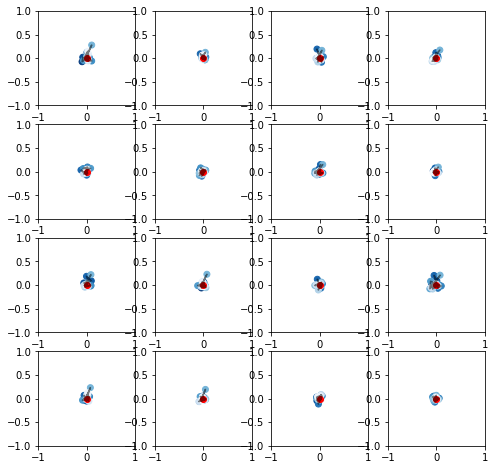

Epoch [501/5000] -----------------------------------------------------------------------------
G: 0.17315745651721953, Dr : 0.17324253916740417, Df : 0.17330941259860994


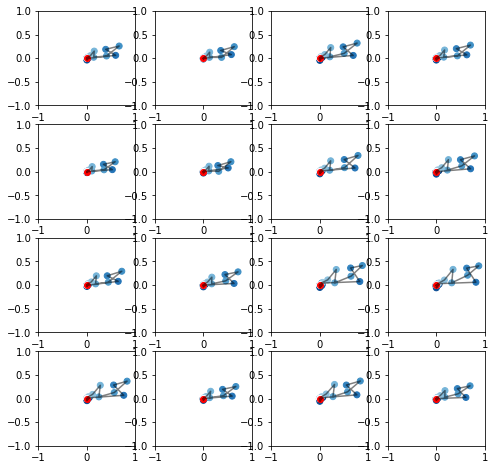

Epoch [1001/5000] -----------------------------------------------------------------------------
G: 0.17345499098300934, Dr : 0.1733112335205078, Df : 0.17334277629852296


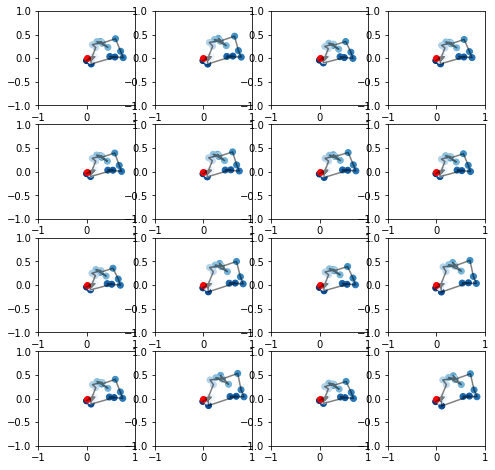

Epoch [1501/5000] -----------------------------------------------------------------------------
G: 0.17332166135311128, Dr : 0.17341502606868744, Df : 0.17336276173591614


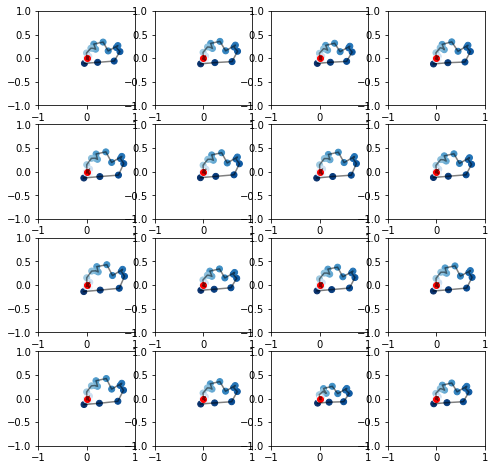

Epoch [2001/5000] -----------------------------------------------------------------------------
G: 0.17315160632133483, Dr : 0.1733533650636673, Df : 0.173258438706398


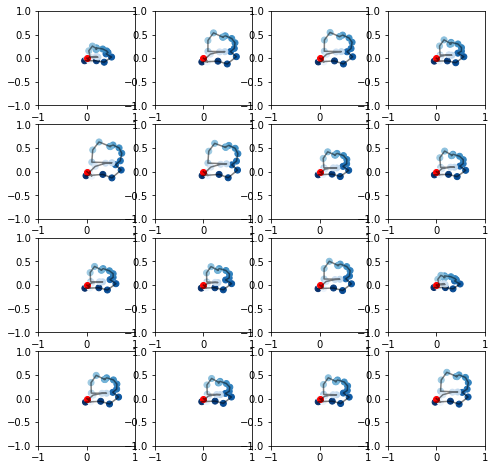

KeyboardInterrupt: ignored

In [28]:
generator = CNNGenerator().to(device)
discriminator = LSTMDiscriminator().to(device)

### WEIGHT INITIALIZATION
generator.apply(weights_init)
discriminator.apply(weights_init)

cnn_lstm = GAN(generator, discriminator, train_loader, device)

# Train the model
nb_epoch = 5000
lr = 0.0002

cnn_lstm.train(nb_epoch, lr, device)